In [24]:
from google.colab import files
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [25]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated!")

Authenticated!


In [26]:
from google.cloud import bigquery

project_id = 'mc-ut-msai-aih-1'
client = bigquery.Client(project=project_id)
print("BigQuery client connected!")

BigQuery client connected!


In [27]:
test_query = "SELECT COUNT(*) as total FROM `physionet-data.mimiciii_clinical.patients`"
print(client.query(test_query).to_dataframe())

   total
0  46520


## Visualization 1: Top 10 Most Prescribed Medications

**Table used:** `prescriptions`

**What this query does:** Counts how many times each drug name appears in the `prescriptions` table across all ICU patients, then sorts to find the 10 most frequently prescribed medications.

**Why it matters:** Prescription frequency reveals what conditions are most commonly managed in the ICU (electrolyte replacement, glycemic control, fluid management, diuresis) and gives a baseline picture of medication burden.

**Chart type:** Horizontal bar chart.

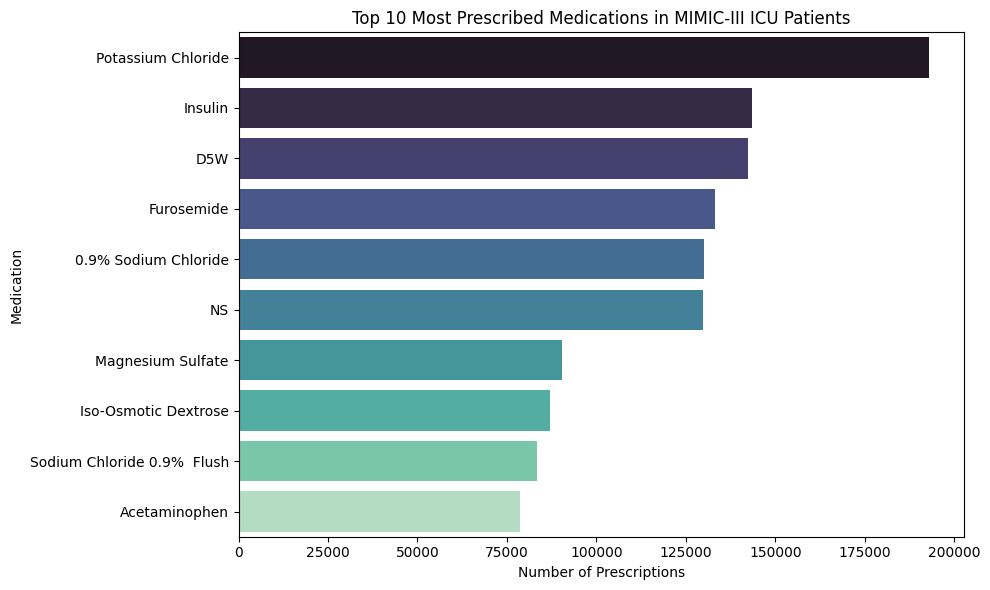

In [28]:
query1 = """
SELECT drug, COUNT(*) as prescription_count
FROM `physionet-data.mimiciii_clinical.prescriptions`
WHERE drug IS NOT NULL
GROUP BY drug
ORDER BY prescription_count DESC
LIMIT 10
"""
df1 = client.query(query1).to_dataframe()

plt.figure(figsize=(10,6))
sns.barplot(x='prescription_count', y='drug', data=df1, hue='drug', palette='mako', legend=False)
plt.title('Top 10 Most Prescribed Medications in MIMIC-III ICU Patients')
plt.xlabel('Number of Prescriptions')
plt.ylabel('Medication')
plt.tight_layout()
plt.show()



## Visualization 2: Top 5 Medications — Prescription Counts by Gender

**Tables used:** `prescriptions` joined with `patients`

**What this query does:** Joins prescriptions to patient demographics on `subject_id`, filters to the 5 most common drugs from Visualization 1, and counts prescriptions per gender for each drug.

**Why it matters:** Shows whether medication usage patterns differ by gender — useful for spotting potential disparities in treatment intensity or case mix.

**Chart type:** Grouped bar chart with `hue='gender'`.

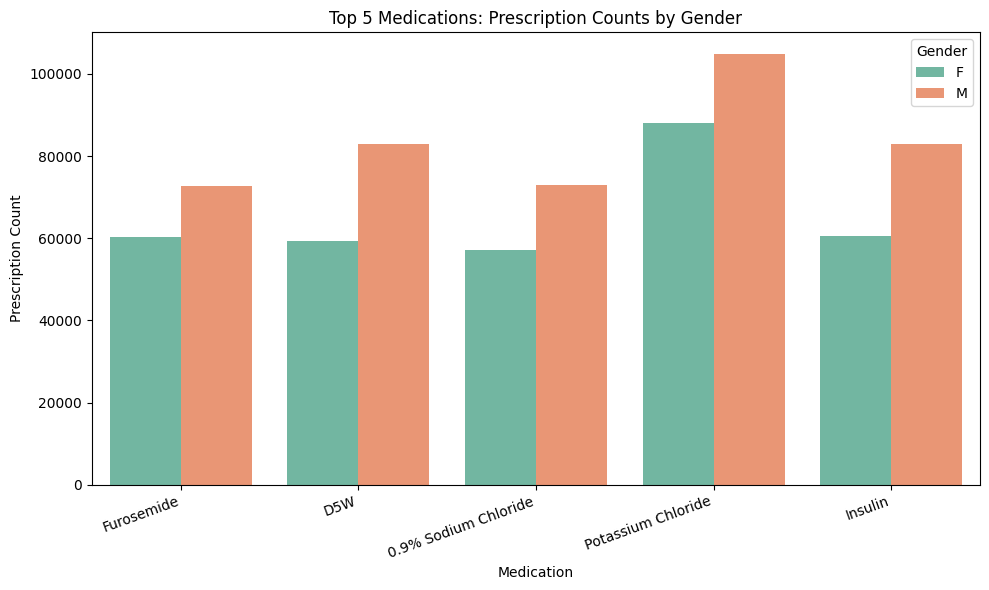

In [29]:
query2 = """
SELECT p.gender, pr.drug, COUNT(*) as count
FROM `physionet-data.mimiciii_clinical.prescriptions` pr
JOIN `physionet-data.mimiciii_clinical.patients` p
ON pr.subject_id = p.subject_id
WHERE pr.drug IN ('Potassium Chloride','Insulin','Furosemide','D5W','0.9% Sodium Chloride')
GROUP BY p.gender, pr.drug
"""
df2 = client.query(query2).to_dataframe()

plt.figure(figsize=(10,6))
sns.barplot(x='drug', y='count', hue='gender', data=df2, palette='Set2')
plt.title('Top 5 Medications: Prescription Counts by Gender')
plt.xlabel('Medication')
plt.ylabel('Prescription Count')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## Visualization 3: Creatinine Levels by Patient Outcome (Survived vs. Died)

**Tables used:** `labevents` joined with `admissions` and `d_labitems`

**What this query does:** Pulls all creatinine lab values (filtered to a clinically plausible range of 0.1–15 mg/dL), joins to the admissions table to label each reading with the patient's in-hospital outcome (`hospital_expire_flag`), and compares the distributions.

**Why it matters:** Creatinine is a key marker of kidney function and a well-known mortality predictor in critically ill patients in general.

**Finding:** In this sample, the median creatinine for survivors and non-survivors is nearly identical (~0.5 mg/dL), and both groups sit well below the 1.2 mg/dL normal upper limit. Creatinine alone does not visibly separate the two outcome groups here.

**Chart type:** Box plot, grouped by outcome. A reference line at 1.2 mg/dL marks the upper limit of normal.

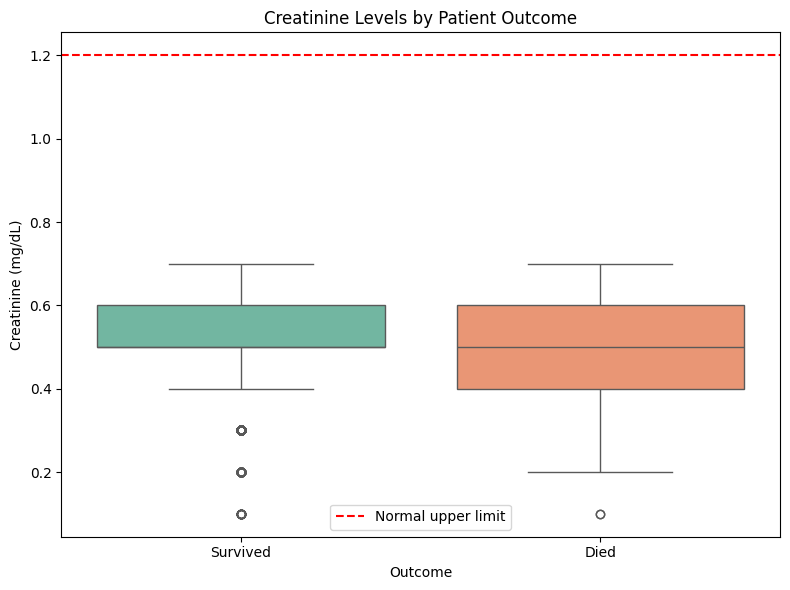

In [30]:
query3 = """
SELECT a.hospital_expire_flag, l.valuenum
FROM `physionet-data.mimiciii_clinical.labevents` l
JOIN `physionet-data.mimiciii_clinical.admissions` a
ON l.hadm_id = a.hadm_id
JOIN `physionet-data.mimiciii_clinical.d_labitems` d
ON l.itemid = d.itemid
WHERE d.label = 'Creatinine'
AND l.valuenum IS NOT NULL
AND l.valuenum BETWEEN 0.1 AND 15
LIMIT 5000
"""
df3 = client.query(query3).to_dataframe()
df3['outcome'] = df3['hospital_expire_flag'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8,6))
sns.boxplot(x='outcome', y='valuenum', data=df3, hue='outcome', palette='Set2', legend=False)
plt.title('Creatinine Levels by Patient Outcome')
plt.xlabel('Outcome')
plt.ylabel('Creatinine (mg/dL)')
plt.axhline(y=1.2, color='red', linestyle='--', label='Normal upper limit')
plt.legend()
plt.tight_layout()
plt.show()

## Visualization 4 (Bonus): Most Common Organisms Cultured

**Table used:** `microbiologyevents`

**What this query does:** Counts the frequency of each organism name recorded in microbiology cultures across the dataset and selects the top 15.

**Why it matters:** Identifies the most clinically significant pathogens encountered in this ICU population (e.g., *S. aureus*, *E. coli*, *K. pneumoniae*), which is foundational for understanding infection patterns and antibiotic stewardship.

**Chart type:** Interactive Plotly treemap, using a different visualization library than Matplotlib/Seaborn.

In [31]:
import plotly.express as px

query4 = """
SELECT org_name, COUNT(*) as count
FROM `physionet-data.mimiciii_clinical.microbiologyevents`
WHERE org_name IS NOT NULL
GROUP BY org_name
ORDER BY count DESC
LIMIT 15
"""
df4 = client.query(query4).to_dataframe()

fig = px.treemap(df4, path=['org_name'], values='count',
                  title='Most Common Organisms Cultured in MIMIC-III Microbiology Events',
                  color='count', color_continuous_scale='Reds')

fig.show()

## Visualization 5: ICU Length of Stay vs. Patient Age

**Tables used:** `icustays` joined with `admissions` and `patients`

**What this query does:** Computes each patient's age at admission (`DATE_DIFF` between admission date and date of birth) and pairs it with their ICU length of stay (`los`), filtered to stays under 30 days to remove extreme outliers.

**Note on MIMIC-III dates:** Patients over 89 years old have their birth dates shifted to appear 300+ years old, per HIPAA de-identification rules. The code filters ages to a plausible 0–120 range to remove this artifact before plotting.

**Finding:** The trendline shows only a very slight positive slope — length of stay is fairly flat across the age range in this sample, with no strong age effect.

**Chart type:** Scatter plot with a linear regression trendline (`sns.regplot`).

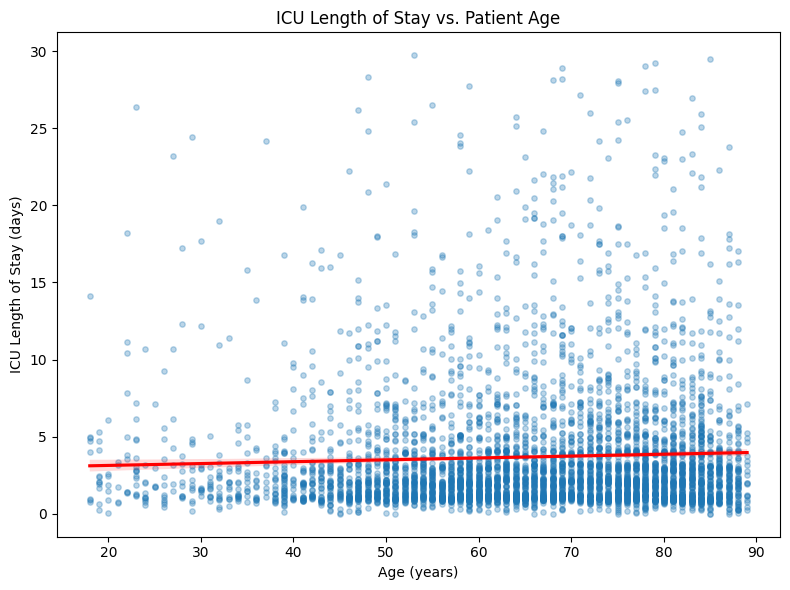

In [32]:
query5 = """
SELECT
  i.los,
  DATE_DIFF(DATE(a.admittime), DATE(p.dob), YEAR) as age
FROM `physionet-data.mimiciii_clinical.icustays` i
JOIN `physionet-data.mimiciii_clinical.admissions` a
ON i.hadm_id = a.hadm_id
JOIN `physionet-data.mimiciii_clinical.patients` p
ON i.subject_id = p.subject_id
WHERE i.los IS NOT NULL
AND i.los BETWEEN 0 AND 30
LIMIT 5000
"""
df5 = client.query(query5).to_dataframe()
df5 = df5[(df5['age'] > 0) & (df5['age'] < 120)]  # filter the 300+ year old artifacts

plt.figure(figsize=(8,6))
sns.regplot(x='age', y='los', data=df5, scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'})
plt.title('ICU Length of Stay vs. Patient Age')
plt.xlabel('Age (years)')
plt.ylabel('ICU Length of Stay (days)')
plt.tight_layout()
plt.show()

## Visualization 6: Creatinine vs. Age, Colored by Outcome

**Tables used:** `labevents` joined with `admissions`, `patients`, and `d_labitems`

**What this query does:** Combines creatinine values, patient age at admission, and in-hospital outcome into a single dataset by joining four tables on `subject_id` / `hadm_id` / `itemid`.

**Why it matters:** Age is a known confounder in many clinical datasets — older patients often have both higher baseline creatinine and higher mortality. Plotting separate trendlines for survivors and non-survivors tests whether that pattern holds here.

**Finding:** The two trendlines are nearly flat and overlap closely across the full age range, both staying well under the 1.2 mg/dL normal limit. In this sample, creatinine does not separate by outcome, and age does not appear to amplify any difference.

**Chart type:** Scatter plot with two separate linear regression trendlines, one per outcome group.

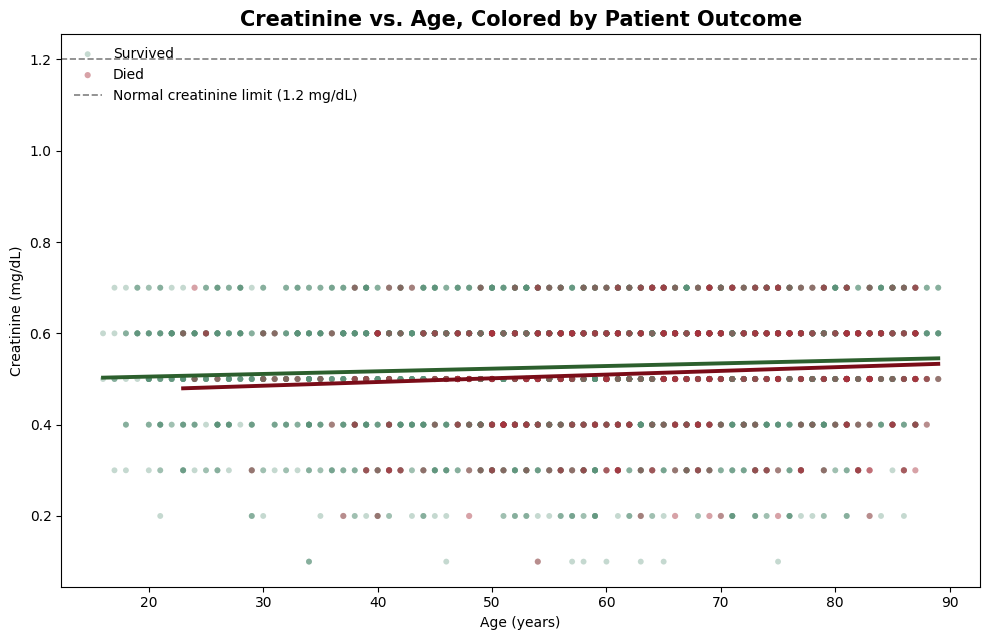

In [33]:
query6 = """
SELECT
  DATE_DIFF(DATE(a.admittime), DATE(p.dob), YEAR) as age,
  l.valuenum as creatinine,
  a.hospital_expire_flag
FROM `physionet-data.mimiciii_clinical.labevents` l
JOIN `physionet-data.mimiciii_clinical.admissions` a
  ON l.hadm_id = a.hadm_id
JOIN `physionet-data.mimiciii_clinical.patients` p
  ON l.subject_id = p.subject_id
JOIN `physionet-data.mimiciii_clinical.d_labitems` d
  ON l.itemid = d.itemid
WHERE d.label = 'Creatinine'
  AND l.valuenum BETWEEN 0.1 AND 15
LIMIT 5000
"""
df6 = client.query(query6).to_dataframe()
df6 = df6[(df6['age'] > 0) & (df6['age'] < 120)]  # remove de-identification age artifacts
df6['outcome'] = df6['hospital_expire_flag'].map({0: 'Survived', 1: 'Died'})

fig, ax = plt.subplots(figsize=(10, 6.5))

surv = df6[df6['outcome'] == 'Survived']
died = df6[df6['outcome'] == 'Died']

ax.scatter(surv['age'], surv['creatinine'], alpha=0.35, s=18, color='#5B9279', label='Survived', edgecolors='none')
ax.scatter(died['age'], died['creatinine'], alpha=0.45, s=20, color='#A8323D', label='Died', edgecolors='none')

# Separate trendline per outcome group
for sub, color in [(surv, '#2C5F2D'), (died, '#7A0C18')]:
    z = np.polyfit(sub['age'], sub['creatinine'], 1)
    p = np.poly1d(z)
    age_range = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    ax.plot(age_range, p(age_range), color=color, linewidth=2.8)

ax.axhline(y=1.2, color='gray', linestyle='--', linewidth=1.2, label='Normal creatinine limit (1.2 mg/dL)')

ax.set_title('Creatinine vs. Age, Colored by Patient Outcome', fontsize=15, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Creatinine (mg/dL)')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()
